Imports 

In [1]:
import zipfile
import json
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

Data table

In [2]:
ZIP_PATH = Path("cifar10 uden model.pt 2.zip")  # change path if needed

records = []
epoch_records = []

with zipfile.ZipFile(ZIP_PATH) as z:
    metric_files = [
        name for name in z.namelist()
        if name.endswith("metrics.json") and not name.startswith("__MACOSX")
    ]

    for file_name in metric_files:
        data = json.loads(z.read(file_name).decode("utf-8"))

        seed_match = re.search(r"seed_(\d+)", file_name)
        gate_match = re.search(r"relu_gate_([0-9.]+)", file_name)

        seed = int(seed_match.group(1)) if seed_match else np.nan
        relu_gate = float(gate_match.group(1)) if gate_match else np.nan

        model = data["stage"]

        model_label_map = {
            "linear_base": "Linear baseline",
            "lora_adapter": "LoRA",
            "quadratic_adapter": "Quadratic"
        }

        model_label = model_label_map.get(model, model)

        train_loss = data["train_loss"]
        test_loss = data["test_loss"]
        train_acc = data["train_acc"]
        test_acc = data["test_acc"]

        records.append({
            "path": file_name,
            "model": model,
            "model_label": model_label,
            "relu_gate": relu_gate,
            "seed": seed,
            "epochs": len(test_acc),
            "final_train_loss": train_loss[-1],
            "final_test_loss": test_loss[-1],
            "final_train_acc": train_acc[-1],
            "final_test_acc": test_acc[-1],
            "best_test_acc": max(test_acc),
            "best_test_acc_epoch": int(np.argmax(test_acc) + 1),
            "min_test_loss": min(test_loss),
            "min_test_loss_epoch": int(np.argmin(test_loss) + 1),
            "training_time_sec": data.get("training_time_sec", np.nan),
        })

        for epoch_idx in range(len(test_acc)):
            epoch_records.append({
                "model": model,
                "model_label": model_label,
                "relu_gate": relu_gate,
                "seed": seed,
                "epoch": epoch_idx + 1,
                "train_loss": train_loss[epoch_idx],
                "test_loss": test_loss[epoch_idx],
                "train_acc": train_acc[epoch_idx],
                "test_acc": test_acc[epoch_idx],
            })

runs = pd.DataFrame(records)
epochs = pd.DataFrame(epoch_records)

runs.head()

,path,model,model_label,relu_gate,seed,epochs,final_train_loss,final_test_loss,final_train_acc,final_test_acc,best_test_acc,best_test_acc_epoch,min_test_loss,min_test_loss_epoch,training_time_sec
0,cifar10 uden model.pt/linear_base/seed_43/metr...,linear_base,Linear baseline,NaN,43,10,0.656634,0.640131,0.77186,0.7815,0.7828,9,0.635875,9,441.183874
1,cifar10 uden model.pt/linear_base/seed_44/metr...,linear_base,Linear baseline,NaN,44,10,0.658593,0.656359,0.77354,0.7768,0.7829,3,0.630760,8,441.829330
2,cifar10 uden model.pt/linear_base/seed_45/metr...,linear_base,Linear baseline,NaN,45,10,0.660739,0.633672,0.77016,0.7844,0.7844,10,0.631752,9,442.991078
3,cifar10 uden model.pt/linear_base/seed_42/metr...,linear_base,Linear baseline,NaN,42,10,0.659319,0.635651,0.77262,0.7799,0.7844,6,0.633907,6,479.806258
4,cifar10 uden model.pt/linear_base/seed_46/metr...,linear_base,Linear baseline,NaN,46,10,0.660232,0.639437,0.77198,0.7826,0.7826,10,0.633065,8,451.099736


Helper Function

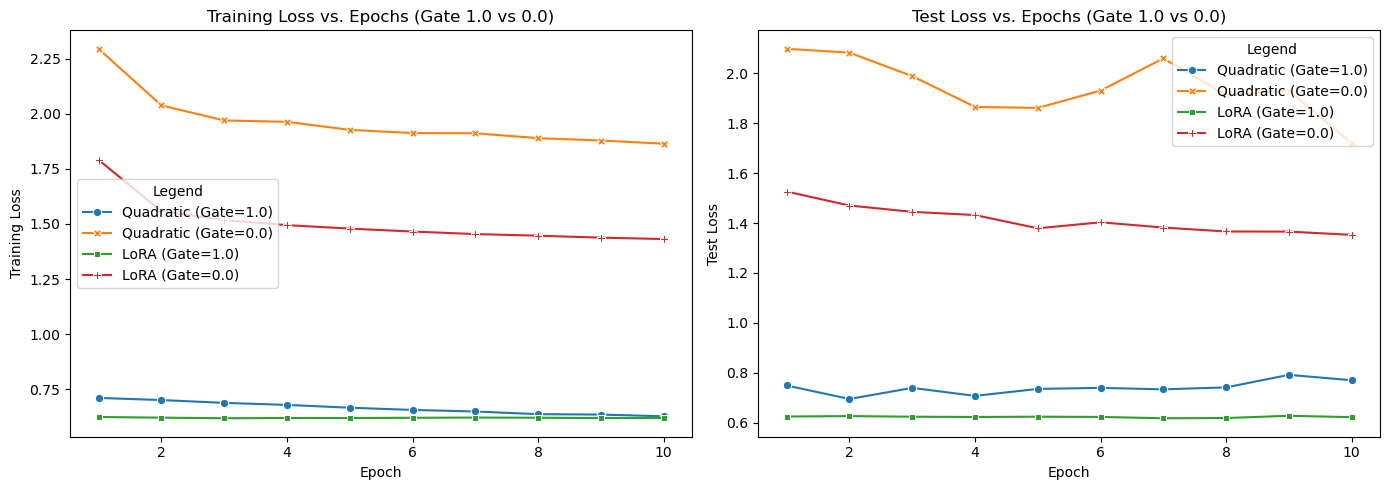

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for the adapters and the specific gates to compare
gates_to_compare = [1.0, 0.0] 
plot_data = epochs[
    (epochs['model'] != 'linear_base') & 
    (epochs['relu_gate'].isin(gates_to_compare))
].copy() # .copy() prevents pandas warnings

# 2. Create a clean, combined label for the legend!
# This will output strings like "LoRA (Gate=1.0)" or "Quadratic (Gate=0.0)"
plot_data['Legend'] = plot_data['model_label'] + " (Gate=" + plot_data['relu_gate'].astype(str) + ")"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3. Plot Training Loss using the new 'Legend' column
sns.lineplot(
    data=plot_data, 
    x='epoch', y='train_loss', 
    hue='Legend', style='Legend', 
    markers=True, dashes=False, # dashes=False keeps all lines solid, easier to read
    errorbar=None, ax=axes[0]
)
axes[0].set_title('Training Loss vs. Epochs (Gate 1.0 vs 0.0)')
axes[0].set_ylabel('Training Loss')
axes[0].set_xlabel('Epoch')

# 4. Plot Test Loss
sns.lineplot(
    data=plot_data, 
    x='epoch', y='test_loss', 
    hue='Legend', style='Legend', 
    markers=True, dashes=False, 
    errorbar=None, ax=axes[1]
)
axes[1].set_title('Test Loss vs. Epochs (Gate 1.0 vs 0.0)')
axes[1].set_ylabel('Test Loss')
axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Filter the data for the full-ReLU models (g=1.0)
overhead_data = epochs[(epochs['model'] != 'linear_base') & (epochs['relu_gate'] == 1.0)]

# 2. Calculate average training time per epoch
time_stats = runs[
    (runs['model'] != 'linear_base') &
    (runs['relu_gate'] == 1.0)
].groupby('model_label')['training_time_sec'].mean()

lora_time = time_stats.get('LoRA', 0) # Adjust 'LoRA' if your exact label is different
quad_time = time_stats.get('Quadratic', 0) # Adjust 'Quadratic' if your exact label is different

if lora_time > 0 and quad_time > 0:
    percent_increase = ((quad_time - lora_time) / lora_time) * 100
    
    print("--- TRAINING TIME OVERHEAD ---")
    print(f"LoRA Average Time/Epoch:      {lora_time:.2f} seconds")
    print(f"Quadratic Average Time/Epoch: {quad_time:.2f} seconds")
    print(f"Overhead Increase:            {percent_increase:.1f}%\n")

# 3. Calculate Convergence Speed (Epoch with the lowest test loss)
# We group by model label, find the index of the minimum test loss, and get that epoch
min_loss_indices = overhead_data.groupby('model_label')['test_loss'].idxmin()
convergence_epochs = overhead_data.loc[min_loss_indices, ['model_label', 'epoch', 'test_loss']]

print("--- CONVERGENCE SPEED (Epoch with lowest Test Loss) ---")
for index, row in convergence_epochs.iterrows():
    print(f"{row['model_label']}: Reached minimum test loss ({row['test_loss']:.4f}) at Epoch {row['epoch']}")

KeyError: 'Column not found: training_time_sec'

In [38]:
def mean_ci_t(x, confidence=0.95):
    """
    t-based confidence interval for the mean.
    Good for small sample sizes, e.g. n=5 seeds.
    """
    x = pd.Series(x).dropna().astype(float).to_numpy()
    n = len(x)

    mean = np.mean(x)
    sd = np.std(x, ddof=1)
    se = sd / np.sqrt(n)

    alpha = 1 - confidence
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)

    ci_low = mean - t_crit * se
    ci_high = mean + t_crit * se

    return pd.Series({
        "n": n,
        "mean": mean,
        "sd": sd,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "ci_half_width": t_crit * se
    })


def holm_correction(p_values):
    """
    Holm-Bonferroni correction without needing statsmodels.
    """
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)

    order = np.argsort(p_values)
    adjusted = np.empty(n)

    running_max = 0

    for rank, idx in enumerate(order):
        corrected = (n - rank) * p_values[idx]
        running_max = max(running_max, corrected)
        adjusted[idx] = min(running_max, 1.0)

    return adjusted


def format_percent(x):
    return f"{100 * x:.2f}%"

Accuracy confidence intervals for each model and ReLU gate

In [4]:
accuracy_summary = (
    runs
    .groupby(["model_label", "model", "relu_gate"], dropna=False)
    ["final_test_acc"]
    .apply(mean_ci_t)
    .unstack()
    .reset_index()
)

accuracy_summary = accuracy_summary.sort_values(
    ["model_label", "relu_gate"],
    na_position="first"
)

accuracy_summary

,model_label,model,relu_gate,n,mean,sd,se,ci_low,ci_high,ci_half_width
0,Linear baseline,linear_base,NaN,5.0,0.78104,0.002881,0.001289,0.777462,0.784618,0.003578
1,LoRA,lora_adapter,0.00,5.0,0.52202,0.008171,0.003654,0.511874,0.532166,0.010146
2,LoRA,lora_adapter,0.25,5.0,0.64952,0.006055,0.002708,0.642001,0.657039,0.007519
3,LoRA,lora_adapter,0.50,5.0,0.71982,0.003927,0.001756,0.714944,0.724696,0.004876
4,LoRA,lora_adapter,0.75,5.0,0.79606,0.002878,0.001287,0.792486,0.799634,0.003574
5,LoRA,lora_adapter,1.00,5.0,0.78868,0.003348,0.001497,0.784523,0.792837,0.004157
6,Quadratic,quadratic_adapter,0.00,5.0,0.50664,0.010029,0.004485,0.494188,0.519092,0.012452
7,Quadratic,quadratic_adapter,0.25,5.0,0.61590,0.015623,0.006987,0.596501,0.635299,0.019399
8,Quadratic,quadratic_adapter,0.50,5.0,0.70326,0.007524,0.003365,0.693918,0.712602,0.009342
9,Quadratic,quadratic_adapter,0.75,5.0,0.77986,0.012496,0.005588,0.764345,0.795375,0.015515


Prettier display

In [5]:
display_summary = accuracy_summary.copy()

for col in ["mean", "ci_low", "ci_high", "ci_half_width", "sd", "se"]:
    display_summary[col] = display_summary[col].apply(lambda x: f"{100*x:.2f}%" if pd.notna(x) else x)

display_summary

,model_label,model,relu_gate,n,mean,sd,se,ci_low,ci_high,ci_half_width
0,Linear baseline,linear_base,NaN,5.0,78.10%,0.29%,0.13%,77.75%,78.46%,0.36%
1,LoRA,lora_adapter,0.00,5.0,52.20%,0.82%,0.37%,51.19%,53.22%,1.01%
2,LoRA,lora_adapter,0.25,5.0,64.95%,0.61%,0.27%,64.20%,65.70%,0.75%
3,LoRA,lora_adapter,0.50,5.0,71.98%,0.39%,0.18%,71.49%,72.47%,0.49%
4,LoRA,lora_adapter,0.75,5.0,79.61%,0.29%,0.13%,79.25%,79.96%,0.36%
5,LoRA,lora_adapter,1.00,5.0,78.87%,0.33%,0.15%,78.45%,79.28%,0.42%
6,Quadratic,quadratic_adapter,0.00,5.0,50.66%,1.00%,0.45%,49.42%,51.91%,1.25%
7,Quadratic,quadratic_adapter,0.25,5.0,61.59%,1.56%,0.70%,59.65%,63.53%,1.94%
8,Quadratic,quadratic_adapter,0.50,5.0,70.33%,0.75%,0.34%,69.39%,71.26%,0.93%
9,Quadratic,quadratic_adapter,0.75,5.0,77.99%,1.25%,0.56%,76.43%,79.54%,1.55%


Normality check for paired differences

For paired t-test, check the differences, not the raw accuracy.

This example checks:

$di​=LoRA$ $accuracy_i​−Quadratic$ $accuracy_i​$

for each ReLU gate

In [32]:
normality_rows = []

for gate in sorted(runs["relu_gate"].dropna().unique()):
    lora = (
        runs[(runs["model"] == "lora_adapter") & (runs["relu_gate"] == gate)]
        .set_index("seed")["final_test_acc"]
    )

    quadratic = (
        runs[(runs["model"] == "quadratic_adapter") & (runs["relu_gate"] == gate)]
        .set_index("seed")["final_test_acc"]
    )

    paired = pd.concat(
        [lora.rename("lora"), quadratic.rename("quadratic")],
        axis=1
    ).dropna()

    diff = paired["lora"] - paired["quadratic"]

    shapiro_stat, shapiro_p = stats.shapiro(diff)

    normality_rows.append({
        "relu_gate": gate,
        "n_pairs": len(diff),
        "mean_diff": diff.mean(),
        "sd_diff": diff.std(ddof=1),
        "shapiro_W": shapiro_stat,
        "shapiro_p": shapiro_p,
        "normality_interpretation": (
    "Normal"
    if shapiro_p >= 0.05
    else "Non-normal"

        )
    })

normality_lora_vs_quadratic = pd.DataFrame(normality_rows)
normality_lora_vs_quadratic

,relu_gate,n_pairs,mean_diff,sd_diff,shapiro_W,shapiro_p,normality_interpretation
0,0.00,5,0.01538,0.009877,0.974472,0.903100,Normal
1,0.25,5,0.03362,0.017724,0.970142,0.876167,Normal
2,0.50,5,0.01656,0.010826,0.974505,0.903300,Normal
3,0.75,5,0.01620,0.011550,0.880829,0.313085,Normal
4,1.00,5,0.02814,0.013106,0.847778,0.187596,Normal


In [33]:
normality_table = normality_lora_vs_quadratic.copy()

normality_table = normality_table.rename(columns={
    "relu_gate": "Gate",
    "n_pairs": "n",
    "mean_diff": "Mean Difference",
    "sd_diff": "SD Difference",
    "shapiro_W": "Shapiro-Wilk $W$",
    "shapiro_p": "$p$-value",
    "normality_interpretation": "Conclusion"
})

print(
    normality_table.round(4).to_latex(
        index=False,
        escape=False,
        caption="Shapiro--Wilk normality tests for paired accuracy differences (LoRA - Quadratic).",
        label="tab:normality"
    )
)

\begin{table}
\caption{Shapiro--Wilk normality tests for paired accuracy differences (LoRA - Quadratic).}
\label{tab:normality}
\begin{tabular}{rrrrrrl}
\toprule
Gate & n & Mean Difference & SD Difference & Shapiro-Wilk $W$ & $p$-value & Conclusion \\
\midrule
0.000000 & 5 & 0.015400 & 0.009900 & 0.974500 & 0.903100 & Normal \\
0.250000 & 5 & 0.033600 & 0.017700 & 0.970100 & 0.876200 & Normal \\
0.500000 & 5 & 0.016600 & 0.010800 & 0.974500 & 0.903300 & Normal \\
0.750000 & 5 & 0.016200 & 0.011500 & 0.880800 & 0.313100 & Normal \\
1.000000 & 5 & 0.028100 & 0.013100 & 0.847800 & 0.187600 & Normal \\
\bottomrule
\end{tabular}
\end{table}



In [34]:
normality_table = normality_lora_vs_quadratic[
    [
        "relu_gate",
        "shapiro_W",
        "shapiro_p",
        "normality_interpretation"
    ]
].rename(columns={
    "relu_gate": "Gate",
    "shapiro_W": "Shapiro--Wilk $W$",
    "shapiro_p": "$p$-value",
    "normality_interpretation": "Conclusion"
})

print(
    normality_table.round(4).to_latex(
        index=False,
        escape=False,
        caption="Normality assessment of paired accuracy differences.",
        label="tab:normality"
    )
)

\begin{table}
\caption{Normality assessment of paired accuracy differences.}
\label{tab:normality}
\begin{tabular}{rrrl}
\toprule
Gate & Shapiro--Wilk $W$ & $p$-value & Conclusion \\
\midrule
0.000000 & 0.974500 & 0.903100 & Normal \\
0.250000 & 0.970100 & 0.876200 & Normal \\
0.500000 & 0.974500 & 0.903300 & Normal \\
0.750000 & 0.880800 & 0.313100 & Normal \\
1.000000 & 0.847800 & 0.187600 & Normal \\
\bottomrule
\end{tabular}
\end{table}



Q-Q plots for the paired differences

This is more useful than only using Shapiro-Wilk, especially because you only have 5 seeds.

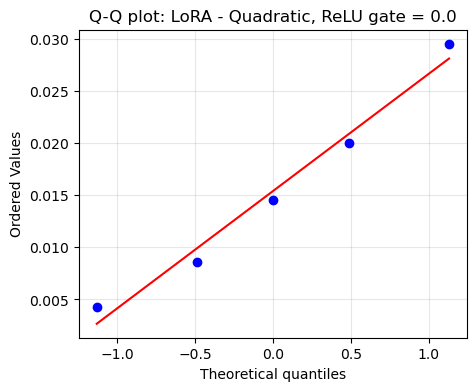

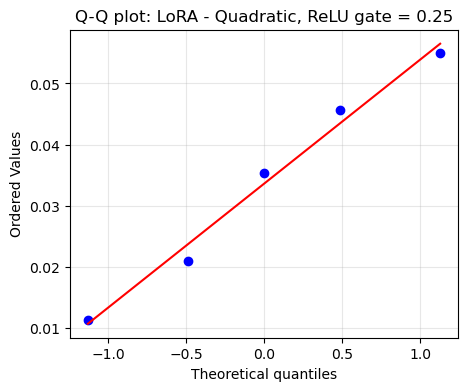

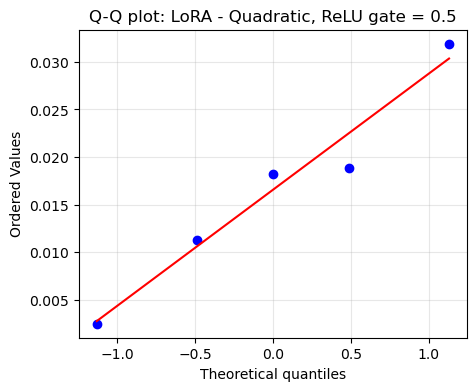

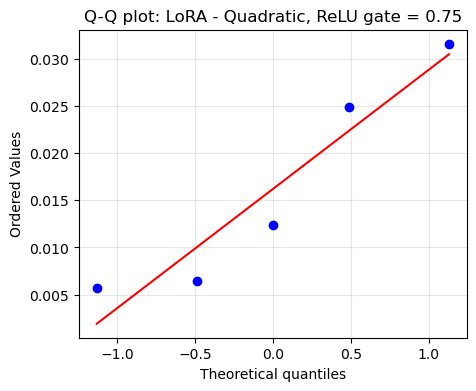

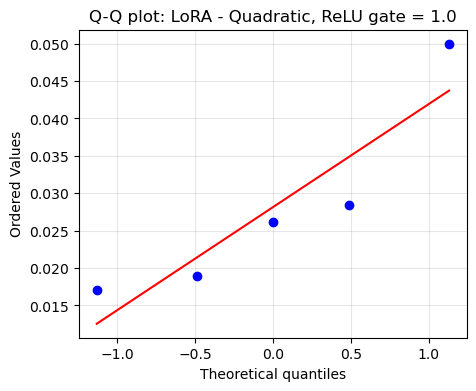

In [7]:
gates = sorted(runs["relu_gate"].dropna().unique())

for gate in gates:
    lora = (
        runs[(runs["model"] == "lora_adapter") & (runs["relu_gate"] == gate)]
        .set_index("seed")["final_test_acc"]
    )

    quadratic = (
        runs[(runs["model"] == "quadratic_adapter") & (runs["relu_gate"] == gate)]
        .set_index("seed")["final_test_acc"]
    )

    paired = pd.concat(
        [lora.rename("lora"), quadratic.rename("quadratic")],
        axis=1
    ).dropna()

    diff = paired["lora"] - paired["quadratic"]

    plt.figure(figsize=(5, 4))
    stats.probplot(diff, dist="norm", plot=plt)
    plt.title(f"Q-Q plot: LoRA - Quadratic, ReLU gate = {gate}")
    plt.grid(alpha=0.3)
    plt.show()

Histogram of paired differences

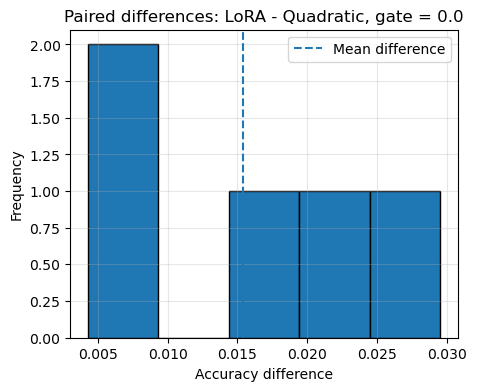

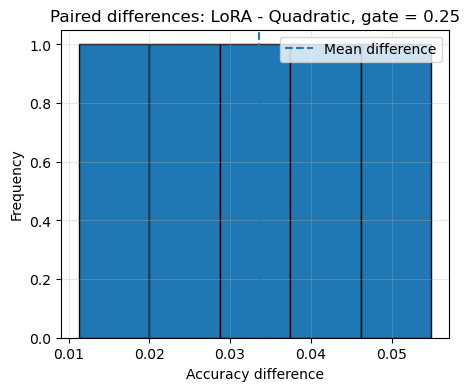

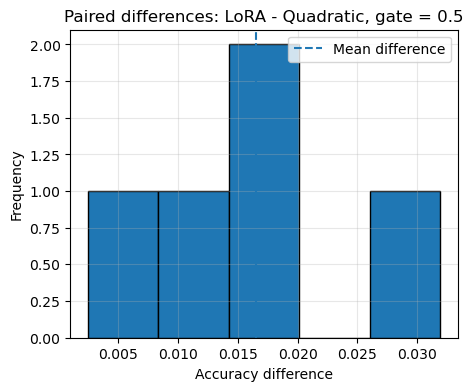

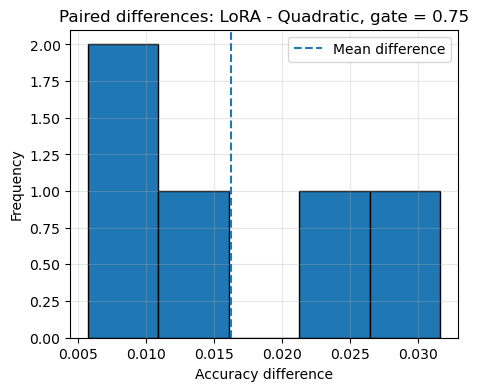

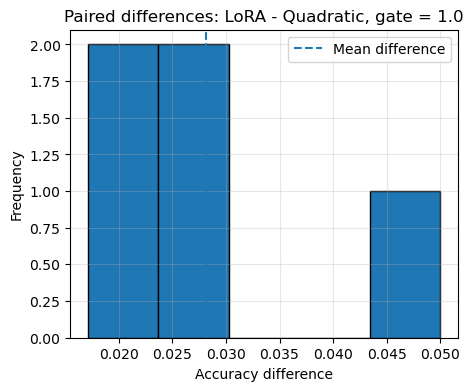

In [8]:
for gate in gates:
    lora = (
        runs[(runs["model"] == "lora_adapter") & (runs["relu_gate"] == gate)]
        .set_index("seed")["final_test_acc"]
    )

    quadratic = (
        runs[(runs["model"] == "quadratic_adapter") & (runs["relu_gate"] == gate)]
        .set_index("seed")["final_test_acc"]
    )

    paired = pd.concat(
        [lora.rename("lora"), quadratic.rename("quadratic")],
        axis=1
    ).dropna()

    diff = paired["lora"] - paired["quadratic"]

    plt.figure(figsize=(5, 4))
    plt.hist(diff, bins=5, edgecolor="black")
    plt.axvline(diff.mean(), linestyle="--", label="Mean difference")
    plt.title(f"Paired differences: LoRA - Quadratic, gate = {gate}")
    plt.xlabel("Accuracy difference")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Paired t-test: LoRA vs Quadratic at each ReLU gate

In [9]:
paired_test_rows = []

for gate in gates:
    lora = (
        runs[(runs["model"] == "lora_adapter") & (runs["relu_gate"] == gate)]
        .set_index("seed")["final_test_acc"]
    )

    quadratic = (
        runs[(runs["model"] == "quadratic_adapter") & (runs["relu_gate"] == gate)]
        .set_index("seed")["final_test_acc"]
    )

    paired = pd.concat(
        [lora.rename("lora"), quadratic.rename("quadratic")],
        axis=1
    ).dropna()

    diff = paired["lora"] - paired["quadratic"]

    t_stat, p_value = stats.ttest_rel(paired["lora"], paired["quadratic"])

    ci = mean_ci_t(diff)

    try:
        wilcoxon_stat, wilcoxon_p = stats.wilcoxon(
            paired["lora"],
            paired["quadratic"],
            zero_method="wilcox"
        )
    except ValueError:
        wilcoxon_stat, wilcoxon_p = np.nan, np.nan

    shapiro_W, shapiro_p = stats.shapiro(diff)

    paired_test_rows.append({
        "relu_gate": gate,
        "n_pairs": len(diff),
        "mean_lora_acc": paired["lora"].mean(),
        "mean_quadratic_acc": paired["quadratic"].mean(),
        "mean_diff_lora_minus_quadratic": diff.mean(),
        "ci95_low_diff": ci["ci_low"],
        "ci95_high_diff": ci["ci_high"],
        "paired_t_stat": t_stat,
        "paired_t_p_uncorrected": p_value,
        "wilcoxon_p_uncorrected": wilcoxon_p,
        "shapiro_p_for_diff": shapiro_p
    })

paired_lora_vs_quadratic = pd.DataFrame(paired_test_rows)

paired_lora_vs_quadratic["paired_t_p_holm"] = holm_correction(
    paired_lora_vs_quadratic["paired_t_p_uncorrected"]
)

paired_lora_vs_quadratic["significant_after_holm_0.05"] = (
    paired_lora_vs_quadratic["paired_t_p_holm"] < 0.05
)

paired_lora_vs_quadratic

,relu_gate,n_pairs,mean_lora_acc,mean_quadratic_acc,mean_diff_lora_minus_quadratic,ci95_low_diff,ci95_high_diff,paired_t_stat,paired_t_p_uncorrected,wilcoxon_p_uncorrected,shapiro_p_for_diff,paired_t_p_holm,significant_after_holm_0.05
0,0.00,5,0.52202,0.50664,0.01538,0.003116,0.027644,3.481867,0.025309,0.0625,0.903100,0.075927,False
1,0.25,5,0.64952,0.61590,0.03362,0.011612,0.055628,4.241401,0.013249,0.0625,0.876167,0.052995,False
2,0.50,5,0.71982,0.70326,0.01656,0.003117,0.030003,3.420320,0.026772,0.0625,0.903300,0.075927,False
3,0.75,5,0.79606,0.77986,0.01620,0.001859,0.030541,3.136391,0.034969,0.0625,0.313085,0.075927,False
4,1.00,5,0.78868,0.76054,0.02814,0.011866,0.044414,4.800929,0.008642,0.0625,0.187596,0.043211,True


Test how much accuracy changes when ReLU is removed

This compares each lower ReLU gate against full ReLU, gate =1.0, within the same model.

In [10]:
gate_vs_full_rows = []

for model in ["lora_adapter", "quadratic_adapter"]:
    model_label = "LoRA" if model == "lora_adapter" else "Quadratic"

    full_relu = (
        runs[(runs["model"] == model) & (runs["relu_gate"] == 1.0)]
        .set_index("seed")["final_test_acc"]
    )

    lower_gates = sorted([
        g for g in runs.loc[runs["model"] == model, "relu_gate"].dropna().unique()
        if g != 1.0
    ])

    for gate in lower_gates:
        lower_relu = (
            runs[(runs["model"] == model) & (runs["relu_gate"] == gate)]
            .set_index("seed")["final_test_acc"]
        )

        paired = pd.concat(
            [lower_relu.rename("lower_gate"), full_relu.rename("full_relu")],
            axis=1
        ).dropna()

        diff = paired["lower_gate"] - paired["full_relu"]

        t_stat, p_value = stats.ttest_rel(
            paired["lower_gate"],
            paired["full_relu"]
        )

        ci = mean_ci_t(diff)

        try:
            wilcoxon_stat, wilcoxon_p = stats.wilcoxon(
                paired["lower_gate"],
                paired["full_relu"],
                zero_method="wilcox"
            )
        except ValueError:
            wilcoxon_stat, wilcoxon_p = np.nan, np.nan

        shapiro_W, shapiro_p = stats.shapiro(diff)

        gate_vs_full_rows.append({
            "model": model_label,
            "lower_relu_gate": gate,
            "reference_gate": 1.0,
            "n_pairs": len(diff),
            "mean_lower_gate_acc": paired["lower_gate"].mean(),
            "mean_full_relu_acc": paired["full_relu"].mean(),
            "mean_diff_lower_minus_full": diff.mean(),
            "ci95_low_diff": ci["ci_low"],
            "ci95_high_diff": ci["ci_high"],
            "paired_t_stat": t_stat,
            "paired_t_p_uncorrected": p_value,
            "wilcoxon_p_uncorrected": wilcoxon_p,
            "shapiro_p_for_diff": shapiro_p
        })

gate_vs_full = pd.DataFrame(gate_vs_full_rows)

gate_vs_full["paired_t_p_holm"] = holm_correction(
    gate_vs_full["paired_t_p_uncorrected"]
)

gate_vs_full["significant_after_holm_0.05"] = (
    gate_vs_full["paired_t_p_holm"] < 0.05
)

gate_vs_full

,model,lower_relu_gate,reference_gate,n_pairs,mean_lower_gate_acc,mean_full_relu_acc,mean_diff_lower_minus_full,ci95_low_diff,ci95_high_diff,paired_t_stat,paired_t_p_uncorrected,wilcoxon_p_uncorrected,shapiro_p_for_diff,paired_t_p_holm,significant_after_holm_0.05
0,LoRA,0.00,1.0,5,0.52202,0.78868,-0.26666,-0.275290,-0.258030,-85.793784,1.106457e-07,0.0625,0.415980,8.851659e-07,True
1,LoRA,0.25,1.0,5,0.64952,0.78868,-0.13916,-0.144626,-0.133694,-70.687878,2.399895e-07,0.0625,0.443869,1.679927e-06,True
2,LoRA,0.50,1.0,5,0.71982,0.78868,-0.06886,-0.076274,-0.061446,-25.787188,1.343364e-05,0.0625,0.906492,7.100172e-05,True
3,LoRA,0.75,1.0,5,0.79606,0.78868,0.00738,0.004744,0.010016,7.773160,1.476727e-03,0.0625,0.922130,2.953454e-03,True
4,Quadratic,0.00,1.0,5,0.50664,0.76054,-0.25390,-0.280380,-0.227420,-26.621950,1.183362e-05,0.0625,0.482760,7.100172e-05,True
5,Quadratic,0.25,1.0,5,0.61590,0.76054,-0.14464,-0.176561,-0.112719,-12.580645,2.297547e-04,0.0625,0.302216,9.190189e-04,True
6,Quadratic,0.50,1.0,5,0.70326,0.76054,-0.05728,-0.075653,-0.038907,-8.655926,9.799632e-04,0.0625,0.973841,2.939890e-03,True
7,Quadratic,0.75,1.0,5,0.77986,0.76054,0.01932,-0.008387,0.047027,1.936037,1.249451e-01,0.1250,0.906013,1.249451e-01,False


Accuracy plot with 95% confidence intervals

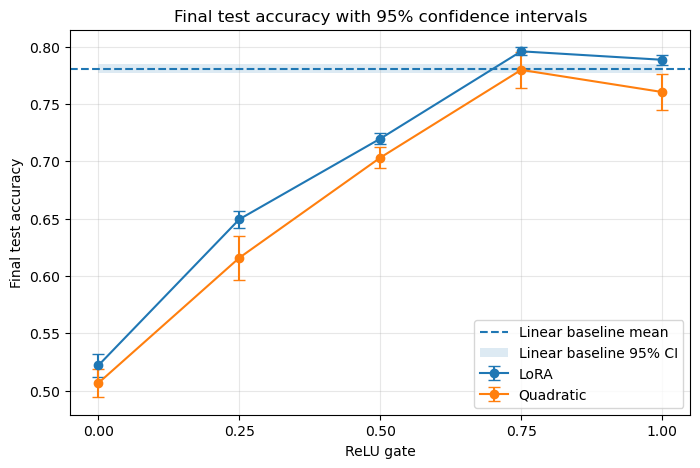

In [11]:
plt.figure(figsize=(8, 5))

for model, label in [
    ("lora_adapter", "LoRA"),
    ("quadratic_adapter", "Quadratic")
]:
    means = []
    yerr_low = []
    yerr_high = []

    for gate in gates:
        values = runs[
            (runs["model"] == model) &
            (runs["relu_gate"] == gate)
        ]["final_test_acc"]

        ci = mean_ci_t(values)

        means.append(ci["mean"])
        yerr_low.append(ci["mean"] - ci["ci_low"])
        yerr_high.append(ci["ci_high"] - ci["mean"])

    plt.errorbar(
        gates,
        means,
        yerr=[yerr_low, yerr_high],
        marker="o",
        capsize=4,
        label=label
    )

# Optional baseline line
baseline_values = runs[runs["model"] == "linear_base"]["final_test_acc"]

if len(baseline_values) > 0:
    baseline_ci = mean_ci_t(baseline_values)

    plt.axhline(
        baseline_ci["mean"],
        linestyle="--",
        label="Linear baseline mean"
    )

    plt.fill_between(
        [min(gates), max(gates)],
        baseline_ci["ci_low"],
        baseline_ci["ci_high"],
        alpha=0.15,
        label="Linear baseline 95% CI"
    )

plt.xlabel("ReLU gate")
plt.ylabel("Final test accuracy")
plt.title("Final test accuracy with 95% confidence intervals")
plt.xticks(gates)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Loss curves by epoch

This helps explain why different settings behave differently during training.

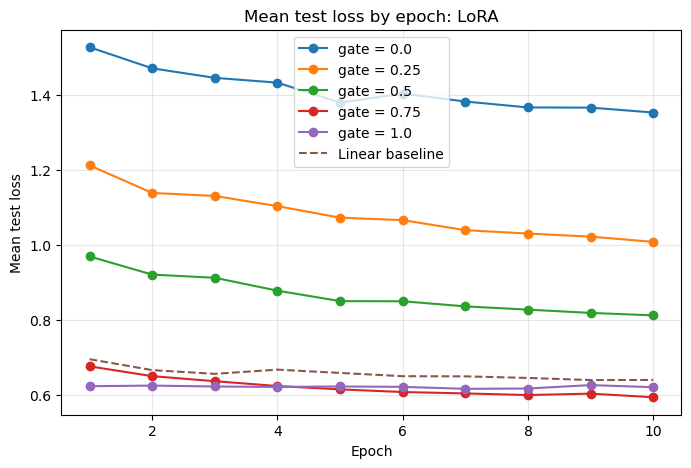

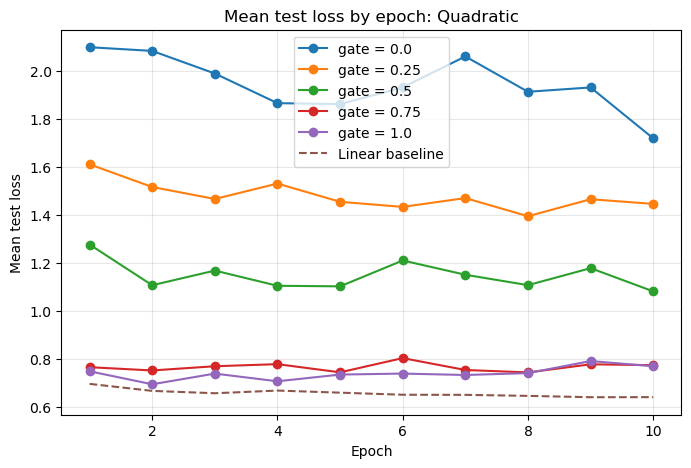

In [12]:
for model, model_label in [
    ("lora_adapter", "LoRA"),
    ("quadratic_adapter", "Quadratic")
]:
    plt.figure(figsize=(8, 5))

    for gate in gates:
        subset = epochs[
            (epochs["model"] == model) &
            (epochs["relu_gate"] == gate)
        ]

        mean_curve = subset.groupby("epoch")["test_loss"].mean()

        plt.plot(
            mean_curve.index,
            mean_curve.values,
            marker="o",
            label=f"gate = {gate}"
        )

    baseline_subset = epochs[epochs["model"] == "linear_base"]

    if len(baseline_subset) > 0:
        baseline_curve = baseline_subset.groupby("epoch")["test_loss"].mean()
        plt.plot(
            baseline_curve.index,
            baseline_curve.values,
            linestyle="--",
            label="Linear baseline"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Mean test loss")
    plt.title(f"Mean test loss by epoch: {model_label}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

For training loss instead of test loss:

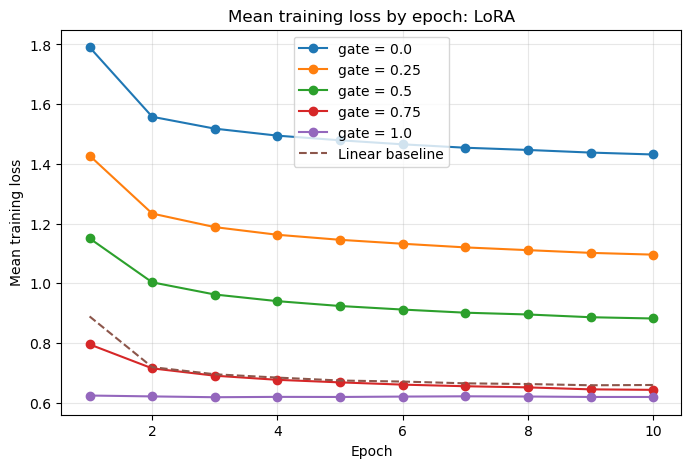

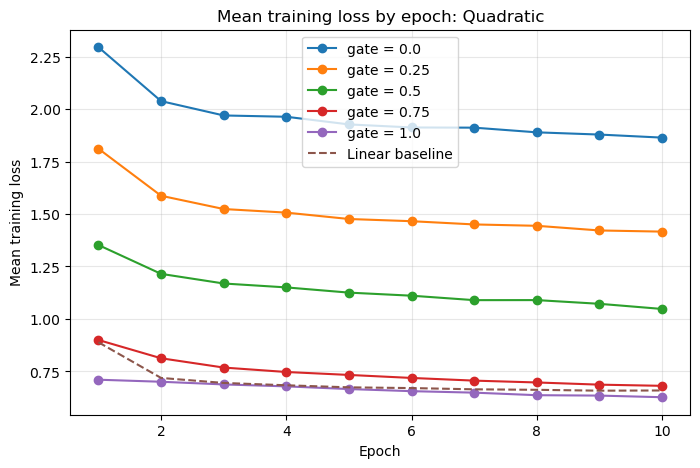

In [13]:
for model, model_label in [
    ("lora_adapter", "LoRA"),
    ("quadratic_adapter", "Quadratic")
]:
    plt.figure(figsize=(8, 5))

    for gate in gates:
        subset = epochs[
            (epochs["model"] == model) &
            (epochs["relu_gate"] == gate)
        ]

        mean_curve = subset.groupby("epoch")["train_loss"].mean()

        plt.plot(
            mean_curve.index,
            mean_curve.values,
            marker="o",
            label=f"gate = {gate}"
        )

    baseline_subset = epochs[epochs["model"] == "linear_base"]

    if len(baseline_subset) > 0:
        baseline_curve = baseline_subset.groupby("epoch")["train_loss"].mean()
        plt.plot(
            baseline_curve.index,
            baseline_curve.values,
            linestyle="--",
            label="Linear baseline"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Mean training loss")
    plt.title(f"Mean training loss by epoch: {model_label}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

Optional: non-parametric bootstrap confidence interval

Use this as a robustness check, not as the main normality test.

This bootstraps the paired differences.

In [14]:
def bootstrap_ci_paired_difference(a, b, n_bootstrap=10000, confidence=0.95, random_state=42):
    rng = np.random.default_rng(random_state)

    a = pd.Series(a).astype(float).to_numpy()
    b = pd.Series(b).astype(float).to_numpy()

    diff = a - b
    n = len(diff)

    bootstrap_means = []

    for _ in range(n_bootstrap):
        sample = rng.choice(diff, size=n, replace=True)
        bootstrap_means.append(sample.mean())

    alpha = 1 - confidence

    ci_low = np.quantile(bootstrap_means, alpha / 2)
    ci_high = np.quantile(bootstrap_means, 1 - alpha / 2)

    return diff.mean(), ci_low, ci_high

Example for LoRA vs Quadratic:

In [15]:
bootstrap_rows = []

for gate in gates:
    lora = (
        runs[(runs["model"] == "lora_adapter") & (runs["relu_gate"] == gate)]
        .set_index("seed")["final_test_acc"]
    )

    quadratic = (
        runs[(runs["model"] == "quadratic_adapter") & (runs["relu_gate"] == gate)]
        .set_index("seed")["final_test_acc"]
    )

    paired = pd.concat(
        [lora.rename("lora"), quadratic.rename("quadratic")],
        axis=1
    ).dropna()

    mean_diff, ci_low, ci_high = bootstrap_ci_paired_difference(
        paired["lora"],
        paired["quadratic"]
    )

    bootstrap_rows.append({
        "relu_gate": gate,
        "mean_diff_lora_minus_quadratic": mean_diff,
        "bootstrap_ci95_low": ci_low,
        "bootstrap_ci95_high": ci_high
    })

bootstrap_lora_vs_quadratic = pd.DataFrame(bootstrap_rows)
bootstrap_lora_vs_quadratic

,relu_gate,mean_diff_lora_minus_quadratic,bootstrap_ci95_low,bootstrap_ci95_high
0,0.00,0.01538,0.00806,0.02342
1,0.25,0.03362,0.01998,0.04726
2,0.50,0.01656,0.00878,0.02518
3,0.75,0.01620,0.00732,0.02522
4,1.00,0.02814,0.01968,0.03948


Table 1: Mean accuracy and 95% CI

In [16]:
summary_table = (
    accuracy_summary[
        ["model_label",
         "relu_gate",
         "mean",
         "ci_low",
         "ci_high"]
    ]
    .rename(columns={
        "model_label": "Model",
        "relu_gate": "Gate",
        "mean": "Mean Accuracy",
        "ci_low": "CI Lower",
        "ci_high": "CI Upper"
    })
)

summary_table["Mean Accuracy"] *= 100
summary_table["CI Lower"] *= 100
summary_table["CI Upper"] *= 100

summary_table.round(2)

,Model,Gate,Mean Accuracy,CI Lower,CI Upper
0,Linear baseline,NaN,78.10,77.75,78.46
1,LoRA,0.00,52.20,51.19,53.22
2,LoRA,0.25,64.95,64.20,65.70
3,LoRA,0.50,71.98,71.49,72.47
4,LoRA,0.75,79.61,79.25,79.96
5,LoRA,1.00,78.87,78.45,79.28
6,Quadratic,0.00,50.66,49.42,51.91
7,Quadratic,0.25,61.59,59.65,63.53
8,Quadratic,0.50,70.33,69.39,71.26
9,Quadratic,0.75,77.99,76.43,79.54


Table 2: Normality test

In [17]:
normality_lora_vs_quadratic[
    [
        "relu_gate",
        "shapiro_W",
        "shapiro_p",
        "normality_interpretation"
    ]
]

,relu_gate,shapiro_W,shapiro_p,normality_interpretation
0,0.00,0.974472,0.903100,No evidence against normality
1,0.25,0.970142,0.876167,No evidence against normality
2,0.50,0.974505,0.903300,No evidence against normality
3,0.75,0.880829,0.313085,No evidence against normality
4,1.00,0.847778,0.187596,No evidence against normality


Table 3: Paired t-test results

In [18]:
paired_lora_vs_quadratic[
    [
        "relu_gate",
        "mean_diff_lora_minus_quadratic",
        "ci95_low_diff",
        "ci95_high_diff",
        "paired_t_p_uncorrected",
        "paired_t_p_holm",
        "wilcoxon_p_uncorrected"
    ]
].round(4)

,relu_gate,mean_diff_lora_minus_quadratic,ci95_low_diff,ci95_high_diff,paired_t_p_uncorrected,paired_t_p_holm,wilcoxon_p_uncorrected
0,0.00,0.0154,0.0031,0.0276,0.0253,0.0759,0.0625
1,0.25,0.0336,0.0116,0.0556,0.0132,0.0530,0.0625
2,0.50,0.0166,0.0031,0.0300,0.0268,0.0759,0.0625
3,0.75,0.0162,0.0019,0.0305,0.0350,0.0759,0.0625
4,1.00,0.0281,0.0119,0.0444,0.0086,0.0432,0.0625


In [25]:
summary_table_display = summary_table.copy()

summary_table_display["95% CI"] = summary_table_display.apply(
    lambda row: f"[{row['CI Lower']:.2f}, {row['CI Upper']:.2f}]",
    axis=1
)

summary_table_display["Gate"] = summary_table_display["Gate"].fillna("-")

summary_table_display = summary_table_display[
    ["Model", "Gate", "Mean Accuracy", "95% CI"]
]

summary_table_display["Mean Accuracy"] = summary_table_display["Mean Accuracy"].round(2)

summary_table_display

,Model,Gate,Mean Accuracy,95% CI
0,Linear baseline,-,78.10,"[77.75, 78.46]"
1,LoRA,0.0,52.20,"[51.19, 53.22]"
2,LoRA,0.25,64.95,"[64.20, 65.70]"
3,LoRA,0.5,71.98,"[71.49, 72.47]"
4,LoRA,0.75,79.61,"[79.25, 79.96]"
5,LoRA,1.0,78.87,"[78.45, 79.28]"
6,Quadratic,0.0,50.66,"[49.42, 51.91]"
7,Quadratic,0.25,61.59,"[59.65, 63.53]"
8,Quadratic,0.5,70.33,"[69.39, 71.26]"
9,Quadratic,0.75,77.99,"[76.43, 79.54]"
